# 03 — Twitch Baseline Ranker

This notebook trains the first ranking models for the Twitch recommendation workload.

## Goal

Given a user and a set of candidate streamers, assign each candidate an inference score:

```text
(user, candidate streamer, features)
                ↓
           ML inference
                ↓
              score
                ↓
      rank candidates by score
```

We compare:

1. Global popularity
2. Logistic Regression
3. Histogram Gradient Boosting

The main question is:

> Can personalized ranking beat the simple strategy of recommending historically popular streamers?

## Evaluation

- ROC-AUC
- Average Precision
- MRR
- Recall@5 / 10 / 20
- HitRate@5 / 10 / 20
- NDCG@5 / 10 / 20

In [1]:
from pathlib import Path
from time import perf_counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42

## 1. Paths

In [2]:
DATA_DIR = Path("../data/processed/twitch")
ARTIFACT_DIR = Path("../artifacts/twitch")
PREDICTION_DIR = DATA_DIR / "predictions"
RESULTS_DIR = Path("../results/03_twitch_baseline_ranker")
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "twitch_train_ranking.csv.gz"
TEST_PATH = DATA_DIR / "twitch_test_ranking.csv.gz"

print("Train data exists:", TRAIN_PATH.exists())
print("Test data exists: ", TEST_PATH.exists())

Train data exists: True
Test data exists:  True


## 2. Load processed ranking data

In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print()
print("Train users:", f"{train['user_id'].nunique():,}")
print("Test users: ", f"{test['user_id'].nunique():,}")
print()
print("Train positive rate:", f"{train['label'].mean():.2%}")
print("Test positive rate: ", f"{test['label'].mean():.2%}")

train.head()

Train shape: (496140, 41)
Test shape:  (240605, 41)

Train users: 20,000
Test users:  10,000

Train positive rate: 20.00%
Test positive rate:  20.00%


,user_id,streamer,user_interactions,user_unique_streamers,user_total_watch_minutes,user_avg_watch_minutes,user_median_watch_minutes,user_active_span_intervals,user_last_activity_recency,user_repeat_rate,user_interactions_last_6_intervals,user_interactions_last_18_intervals,user_interactions_last_42_intervals,streamer_interactions,streamer_unique_viewers,streamer_total_watch_minutes,streamer_avg_watch_minutes,streamer_popularity_share,streamer_log_interactions,streamer_log_viewers,streamer_repeat_viewer_rate,streamer_interactions_last_6,streamer_interactions_last_18,streamer_interactions_last_42,streamer_interactions_prev_42,streamer_trend_ratio,pair_interactions,pair_watch_minutes,pair_avg_watch_minutes,pair_recency_intervals,pair_active_span_intervals,pair_repeat_strength,pair_interactions_last_6,pair_interactions_last_18,pair_interactions_last_42,seen_before,pair_interaction_share,pair_watch_share,label,future_interactions,future_watch_minutes
0,1,esl_csgo,27,13,590,21.8519,10.0000,4173,49,0.5185,0.0000,0.0000,0.0000,"11,454.0000","4,836.0000","366,670.0000",32.0124,0.0054,9.3462,8.4840,0.4957,8.0000,49.0000,172.0000,274.0000,0.6291,0.0000,0.0000,0.0000,"4,377.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,1,1.0000,10.0000
1,1,h3x_tv,27,13,590,21.8519,10.0000,4173,49,0.5185,0.0000,0.0000,0.0000,1.0000,1.0000,10.0000,10.0000,0.0000,0.6931,0.6931,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,"4,377.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,1,1.0000,10.0000
2,1,jahrein,27,13,590,21.8519,10.0000,4173,49,0.5185,0.0000,0.0000,0.0000,"1,679.0000",837.0000,"50,290.0000",29.9524,0.0008,7.4265,6.7310,0.4934,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,30.0000,30.0000,619.0000,0.0000,0.6931,0.0000,0.0000,0.0000,1,0.0370,0.0508,1,1.0000,20.0000
3,1,jrokezftw,27,13,590,21.8519,10.0000,4173,49,0.5185,0.0000,0.0000,0.0000,"1,032.0000",499.0000,"31,020.0000",30.0581,0.0005,6.9402,6.2146,0.4629,0.0000,0.0000,0.0000,30.0000,0.0323,1.0000,30.0000,30.0000,"3,785.0000",0.0000,0.6931,0.0000,0.0000,0.0000,1,0.0370,0.0508,1,1.0000,10.0000
4,1,ogrencievi,27,13,590,21.8519,10.0000,4173,49,0.5185,0.0000,0.0000,0.0000,184.0000,119.0000,"4,250.0000",23.0978,0.0001,5.2204,4.7875,0.3697,0.0000,0.0000,0.0000,8.0000,0.1111,1.0000,10.0000,10.0000,172.0000,0.0000,0.6931,0.0000,0.0000,0.0000,1,0.0370,0.0169,1,2.0000,40.0000


## 3. Define feature columns

In [4]:
ID_COLUMNS = ["user_id", "streamer"]
LABEL_COLUMN = "label"
FUTURE_ONLY_COLUMNS = [
    "future_interactions",
    "future_watch_minutes",
]

EXCLUDED_COLUMNS = (
    ID_COLUMNS
    + [LABEL_COLUMN]
    + FUTURE_ONLY_COLUMNS
)

FEATURE_COLUMNS = [
    c for c in train.columns
    if c not in EXCLUDED_COLUMNS
]

print(f"Number of model features: {len(FEATURE_COLUMNS)}")
FEATURE_COLUMNS

Number of model features: 36


['user_interactions',
 'user_unique_streamers',
 'user_total_watch_minutes',
 'user_avg_watch_minutes',
 'user_median_watch_minutes',
 'user_active_span_intervals',
 'user_last_activity_recency',
 'user_repeat_rate',
 'user_interactions_last_6_intervals',
 'user_interactions_last_18_intervals',
 'user_interactions_last_42_intervals',
 'streamer_interactions',
 'streamer_unique_viewers',
 'streamer_total_watch_minutes',
 'streamer_avg_watch_minutes',
 'streamer_popularity_share',
 'streamer_log_interactions',
 'streamer_log_viewers',
 'streamer_repeat_viewer_rate',
 'streamer_interactions_last_6',
 'streamer_interactions_last_18',
 'streamer_interactions_last_42',
 'streamer_interactions_prev_42',
 'streamer_trend_ratio',
 'pair_interactions',
 'pair_watch_minutes',
 'pair_avg_watch_minutes',
 'pair_recency_intervals',
 'pair_active_span_intervals',
 'pair_repeat_strength',
 'pair_interactions_last_6',
 'pair_interactions_last_18',
 'pair_interactions_last_42',
 'seen_before',
 'pair_in

## 4. Leakage and missing-value checks

In [5]:
assert LABEL_COLUMN not in FEATURE_COLUMNS
assert "user_id" not in FEATURE_COLUMNS
assert "streamer" not in FEATURE_COLUMNS
assert not set(FUTURE_ONLY_COLUMNS).intersection(FEATURE_COLUMNS)

missing_summary = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "train_missing": [train[c].isna().sum() for c in FEATURE_COLUMNS],
        "test_missing": [test[c].isna().sum() for c in FEATURE_COLUMNS],
    }
)

display(
    missing_summary[
        (missing_summary["train_missing"] > 0)
        | (missing_summary["test_missing"] > 0)
    ]
)

print("Leakage check passed.")

,feature,train_missing,test_missing
11,streamer_interactions,6310,2550
12,streamer_unique_viewers,6310,2550
13,streamer_total_watch_minutes,6310,2550
14,streamer_avg_watch_minutes,6310,2550
15,streamer_popularity_share,6310,2550
16,streamer_log_interactions,6310,2550
17,streamer_log_viewers,6310,2550
18,streamer_repeat_viewer_rate,6310,2550
19,streamer_interactions_last_6,6310,2550
20,streamer_interactions_last_18,6310,2550


Leakage check passed.


## 5. Ranking metric function

In [6]:
def evaluate_ranking(frame, score_column, ks=(5, 10, 20)):
    ranked = frame.sort_values(
        ["user_id", score_column],
        ascending=[True, False],
    )

    user_results = []

    for user_id, group in ranked.groupby("user_id", sort=False):
        labels = group["label"].to_numpy(dtype=np.int8)
        total_positives = int(labels.sum())

        if total_positives == 0:
            continue

        row = {"user_id": user_id}

        positive_positions = np.flatnonzero(labels == 1)
        first_positive_rank = positive_positions[0] + 1
        row["MRR"] = 1.0 / first_positive_rank

        for k in ks:
            k_effective = min(k, len(labels))
            top_labels = labels[:k_effective]
            hits = int(top_labels.sum())

            row[f"Recall@{k}"] = hits / total_positives
            row[f"HitRate@{k}"] = float(hits > 0)

            discounts = 1.0 / np.log2(
                np.arange(2, k_effective + 2)
            )

            dcg = (top_labels * discounts).sum()

            ideal_positive_count = min(
                total_positives,
                k_effective,
            )

            ideal_discounts = 1.0 / np.log2(
                np.arange(2, ideal_positive_count + 2)
            )

            idcg = ideal_discounts.sum()

            row[f"NDCG@{k}"] = (
                dcg / idcg
                if idcg > 0
                else np.nan
            )

        user_results.append(row)

    per_user = pd.DataFrame(user_results)

    summary = {
        "model": score_column,
        "MRR": per_user["MRR"].mean(),
    }

    for k in ks:
        summary[f"Recall@{k}"] = per_user[f"Recall@{k}"].mean()
        summary[f"HitRate@{k}"] = per_user[f"HitRate@{k}"].mean()
        summary[f"NDCG@{k}"] = per_user[f"NDCG@{k}"].mean()

    return pd.Series(summary), per_user

## 6. Popularity baseline

In [7]:
baseline_predictions = test[
    [
        "user_id",
        "streamer",
        "label",
        "seen_before",
        "streamer_interactions",
        "streamer_popularity_share",
    ]
].copy()

baseline_predictions["score_popularity"] = (
    baseline_predictions["streamer_interactions"].fillna(0)
)

popularity_auc = roc_auc_score(
    baseline_predictions["label"],
    baseline_predictions["score_popularity"],
)

popularity_ap = average_precision_score(
    baseline_predictions["label"],
    baseline_predictions["score_popularity"],
)

popularity_ranking_summary, popularity_per_user = evaluate_ranking(
    baseline_predictions,
    "score_popularity",
)

print("Popularity ROC-AUC:", f"{popularity_auc:.4f}")
print("Popularity AP:", f"{popularity_ap:.4f}")
display(popularity_ranking_summary)

Popularity ROC-AUC: 0.8119
Popularity AP: 0.7189


model         score_popularity
MRR                     0.8796
Recall@5                0.7397
HitRate@5               0.9767
NDCG@5                  0.8114
Recall@10               0.8611
HitRate@10              0.9932
NDCG@10                 0.8244
Recall@20               0.9344
HitRate@20              0.9985
NDCG@20                 0.8444
dtype: object

## 7. Logistic Regression

In [8]:
X_train = train[FEATURE_COLUMNS]
y_train = train[LABEL_COLUMN].astype(int)

X_test = test[FEATURE_COLUMNS]
y_test = test[LABEL_COLUMN].astype(int)

logistic_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=500,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

start = perf_counter()
logistic_model.fit(X_train, y_train)
logistic_training_seconds = perf_counter() - start

print(
    "Logistic training time:",
    f"{logistic_training_seconds:.2f} sec"
)

Logistic training time: 2.28 sec


In [9]:
start = perf_counter()

logistic_scores = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_inference_seconds = perf_counter() - start

logistic_throughput = (
    len(X_test) / logistic_inference_seconds
)

baseline_predictions["score_logistic"] = logistic_scores

logistic_auc = roc_auc_score(
    y_test,
    logistic_scores,
)

logistic_ap = average_precision_score(
    y_test,
    logistic_scores,
)

logistic_ranking_summary, logistic_per_user = evaluate_ranking(
    baseline_predictions,
    "score_logistic",
)

print("ROC-AUC:", f"{logistic_auc:.4f}")
print("Average Precision:", f"{logistic_ap:.4f}")
print(
    "Inference throughput:",
    f"{logistic_throughput:,.0f} rows/sec"
)

display(logistic_ranking_summary)

ROC-AUC: 0.9167
Average Precision: 0.8610
Inference throughput: 3,354,028 rows/sec


model         score_logistic
MRR                   0.9595
Recall@5              0.7941
HitRate@5             0.9938
NDCG@5                0.9112
Recall@10             0.9058
HitRate@10            0.9992
NDCG@10               0.9131
Recall@20             0.9620
HitRate@20            0.9998
NDCG@20               0.9225
dtype: object

## 7.1 Logistic Regression feature coefficients

In [10]:
logistic_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "coefficient": logistic_coefficients,
        "abs_coefficient": np.abs(logistic_coefficients),
    }
).sort_values(
    "abs_coefficient",
    ascending=False,
)

coefficient_table.head(20)

,feature,coefficient,abs_coefficient
17,streamer_log_viewers,1.9781,1.9781
33,seen_before,1.3712,1.3712
16,streamer_log_interactions,-0.7485,0.7485
12,streamer_unique_viewers,0.7464,0.7464
29,pair_repeat_strength,0.5754,0.5754
34,pair_interaction_share,0.4013,0.4013
15,streamer_popularity_share,-0.3819,0.3819
11,streamer_interactions,-0.3819,0.3819
35,pair_watch_share,0.2439,0.2439
1,user_unique_streamers,0.2270,0.2270


## 8. Histogram Gradient Boosting

In [11]:
hgb_imputer = SimpleImputer(strategy="median")

X_train_hgb = hgb_imputer.fit_transform(X_train)
X_test_hgb = hgb_imputer.transform(X_test)

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_SEED,
)

start = perf_counter()
hgb_model.fit(X_train_hgb, y_train)
hgb_training_seconds = perf_counter() - start

print(
    "HGB training time:",
    f"{hgb_training_seconds:.2f} sec"
)

HGB training time: 7.73 sec


In [12]:
start = perf_counter()

hgb_scores = hgb_model.predict_proba(
    X_test_hgb
)[:, 1]

hgb_inference_seconds = perf_counter() - start
hgb_throughput = len(X_test_hgb) / hgb_inference_seconds

baseline_predictions["score_hgb"] = hgb_scores

hgb_auc = roc_auc_score(
    y_test,
    hgb_scores,
)

hgb_ap = average_precision_score(
    y_test,
    hgb_scores,
)

hgb_ranking_summary, hgb_per_user = evaluate_ranking(
    baseline_predictions,
    "score_hgb",
)

print("ROC-AUC:", f"{hgb_auc:.4f}")
print("Average Precision:", f"{hgb_ap:.4f}")
print(
    "Inference throughput:",
    f"{hgb_throughput:,.0f} rows/sec"
)

display(hgb_ranking_summary)

ROC-AUC: 0.9637
Average Precision: 0.9263
Inference throughput: 559,402 rows/sec


model         score_hgb
MRR              0.9855
Recall@5         0.8340
HitRate@5        0.9996
NDCG@5           0.9595
Recall@10        0.9393
HitRate@10       1.0000
NDCG@10          0.9606
Recall@20        0.9829
HitRate@20       1.0000
NDCG@20          0.9655
dtype: object

## 9. Compare all baselines

In [13]:
classification_comparison = pd.DataFrame(
    {
        "model": [
            "popularity",
            "logistic",
            "hgb",
        ],
        "ROC_AUC": [
            popularity_auc,
            logistic_auc,
            hgb_auc,
        ],
        "AveragePrecision": [
            popularity_ap,
            logistic_ap,
            hgb_ap,
        ],
        "training_seconds": [
            0.0,
            logistic_training_seconds,
            hgb_training_seconds,
        ],
        "inference_seconds": [
            np.nan,
            logistic_inference_seconds,
            hgb_inference_seconds,
        ],
        "inference_rows_per_sec": [
            np.nan,
            logistic_throughput,
            hgb_throughput,
        ],
    }
)

ranking_comparison = pd.DataFrame(
    [
        popularity_ranking_summary,
        logistic_ranking_summary,
        hgb_ranking_summary,
    ]
)

display(classification_comparison)
display(ranking_comparison)

,model,ROC_AUC,AveragePrecision,training_seconds,inference_seconds,inference_rows_per_sec
0,popularity,0.8119,0.7189,0.0000,NaN,NaN
1,logistic,0.9167,0.8610,2.2816,0.0717,"3,354,028.3930"
2,hgb,0.9637,0.9263,7.7269,0.4301,"559,401.8906"


,model,MRR,Recall@5,HitRate@5,NDCG@5,Recall@10,HitRate@10,NDCG@10,Recall@20,HitRate@20,NDCG@20
0,score_popularity,0.8796,0.7397,0.9767,0.8114,0.8611,0.9932,0.8244,0.9344,0.9985,0.8444
1,score_logistic,0.9595,0.7941,0.9938,0.9112,0.9058,0.9992,0.9131,0.9620,0.9998,0.9225
2,score_hgb,0.9855,0.8340,0.9996,0.9595,0.9393,1.0000,0.9606,0.9829,1.0000,0.9655


## 10. Plot NDCG@10

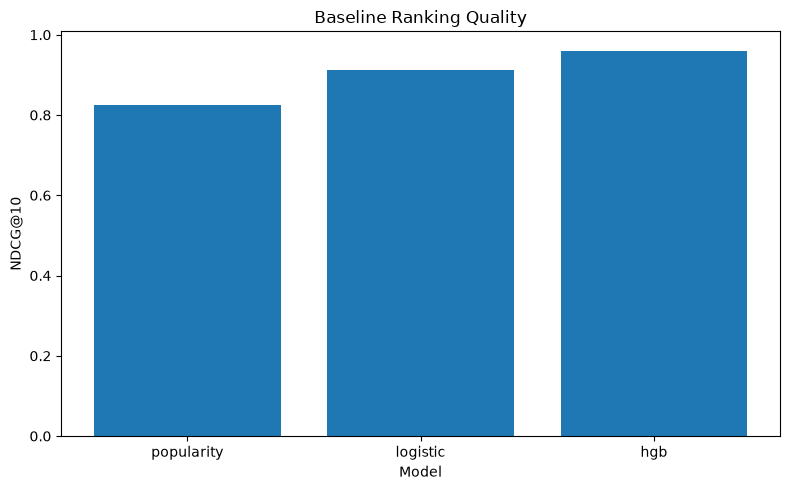

In [14]:
plot_df = ranking_comparison.copy()

plot_df["model"] = (
    plot_df["model"]
    .str.replace("score_", "", regex=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["model"],
    plot_df["NDCG@10"],
)

plt.xlabel("Model")
plt.ylabel("NDCG@10")
plt.title("Baseline Ranking Quality")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "baseline_ndcg_at_10.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## 11. Plot Recall@10

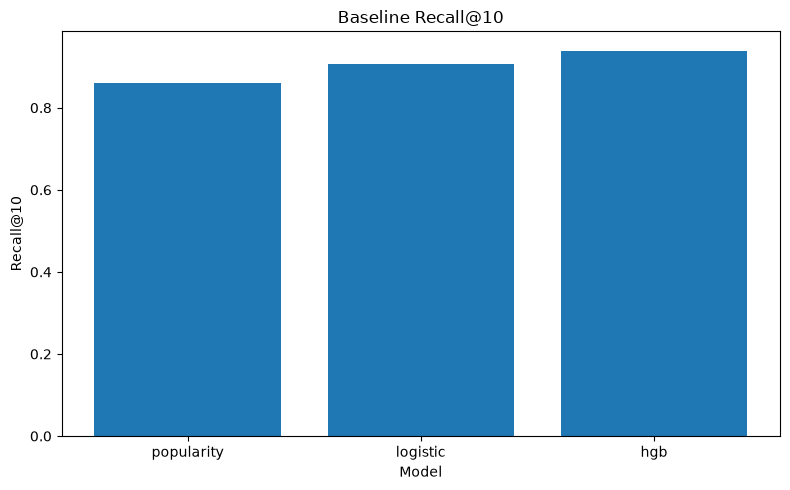

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["model"],
    plot_df["Recall@10"],
)

plt.xlabel("Model")
plt.ylabel("Recall@10")
plt.title("Baseline Recall@10")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "baseline_recall_at_10.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## 12. Repeat vs new-streamer positives

In [16]:
positive_score_analysis = (
    baseline_predictions[
        baseline_predictions["label"] == 1
    ]
    .copy()
)

positive_score_analysis["positive_type"] = np.where(
    positive_score_analysis["seen_before"] == 1,
    "Repeat streamer",
    "New streamer",
)

repeat_vs_new_scores = (
    positive_score_analysis
    .groupby("positive_type")
    .agg(
        positive_pairs=("label", "size"),
        popularity_mean_score=("score_popularity", "mean"),
        logistic_mean_score=("score_logistic", "mean"),
        hgb_mean_score=("score_hgb", "mean"),
    )
    .reset_index()
)

repeat_vs_new_scores

,positive_type,positive_pairs,popularity_mean_score,logistic_mean_score,hgb_mean_score
0,New streamer,21719,"1,761.7876",0.3157,0.5236
1,Repeat streamer,26402,"3,518.7683",0.9959,0.9955


## 13. Inspect one user's ranking

In [17]:
example_user = baseline_predictions["user_id"].iloc[0]

example_ranking = (
    baseline_predictions[
        baseline_predictions["user_id"] == example_user
    ]
    .sort_values(
        "score_hgb",
        ascending=False,
    )
)

print("Example user:", example_user)

display(
    example_ranking[
        [
            "streamer",
            "label",
            "seen_before",
            "score_popularity",
            "score_logistic",
            "score_hgb",
        ]
    ].head(20)
)

Example user: 1


,streamer,label,seen_before,score_popularity,score_logistic,score_hgb
4,mithrain,1,1,"4,950.0000",0.9999,0.9996
6,wtcn,1,1,"3,301.0000",0.9998,0.9994
3,kendinemuzisyen,1,1,"3,247.0000",0.9999,0.9992
1,jahrein,1,1,"2,286.0000",0.9995,0.9974
5,towshun,1,1,27.0000,0.9934,0.9955
48130,innocents,0,0,996.0000,0.4864,0.5908
0,grimnax,1,0,777.0000,0.3952,0.5384
2,jtgtv,1,0,217.0000,0.6675,0.5382
48133,wtf_winds123,0,0,746.0000,0.3090,0.4757
48148,floyl,0,0,74.0000,0.0900,0.0983


## 14. Save models and predictions

In [18]:
LOGISTIC_MODEL_PATH = (
    ARTIFACT_DIR
    / "baseline_logistic_regression.joblib"
)

joblib.dump(
    logistic_model,
    LOGISTIC_MODEL_PATH,
)

HGB_MODEL_PATH = (
    ARTIFACT_DIR
    / "baseline_hist_gradient_boosting.joblib"
)

joblib.dump(
    {
        "imputer": hgb_imputer,
        "model": hgb_model,
        "feature_columns": FEATURE_COLUMNS,
    },
    HGB_MODEL_PATH,
)

PREDICTION_PATH = (
    PREDICTION_DIR
    / "baseline_predictions.csv.gz"
)

baseline_predictions.to_csv(
    PREDICTION_PATH,
    index=False,
    compression="gzip",
)

print("Saved:")
print(LOGISTIC_MODEL_PATH)
print(HGB_MODEL_PATH)
print(PREDICTION_PATH)

Saved:
../artifacts/twitch/baseline_logistic_regression.joblib
../artifacts/twitch/baseline_hist_gradient_boosting.joblib
../data/processed/twitch/predictions/baseline_predictions.csv.gz


## 15. Save Notebook 03 results

In [19]:
result_tables = {
    "classification_comparison": classification_comparison,
    "ranking_comparison": ranking_comparison,
    "logistic_coefficients": coefficient_table,
    "repeat_vs_new_scores": repeat_vs_new_scores,
    "example_ranking": example_ranking.head(100),
}

for name, table in result_tables.items():
    table.to_csv(
        TABLES_DIR / f"{name}.csv",
        index=False,
    )

key_metrics = pd.DataFrame(
    [
        {
            "model": "popularity",
            "ROC_AUC": popularity_auc,
            "AveragePrecision": popularity_ap,
            "MRR": popularity_ranking_summary["MRR"],
            "Recall@10": popularity_ranking_summary["Recall@10"],
            "NDCG@10": popularity_ranking_summary["NDCG@10"],
        },
        {
            "model": "logistic",
            "ROC_AUC": logistic_auc,
            "AveragePrecision": logistic_ap,
            "MRR": logistic_ranking_summary["MRR"],
            "Recall@10": logistic_ranking_summary["Recall@10"],
            "NDCG@10": logistic_ranking_summary["NDCG@10"],
        },
        {
            "model": "hgb",
            "ROC_AUC": hgb_auc,
            "AveragePrecision": hgb_ap,
            "MRR": hgb_ranking_summary["MRR"],
            "Recall@10": hgb_ranking_summary["Recall@10"],
            "NDCG@10": hgb_ranking_summary["NDCG@10"],
        },
    ]
)

key_metrics.to_csv(
    RESULTS_DIR / "key_metrics.csv",
    index=False,
)

print(
    "Results saved to:",
    RESULTS_DIR.resolve()
)

Results saved to: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/03_twitch_baseline_ranker


# Notebook 03 Outcome

At the end of this notebook we have:

```text
Popularity baseline
        ↓
Logistic Regression
        ↓
Histogram Gradient Boosting
        ↓
classification metrics
+
per-user ranking metrics
        ↓
saved models + predictions
```

The next notebook is:

**04_twitch_neural_ranker.ipynb**

The key question will be:

> Does a neural ranker improve recommendation quality enough to justify a more expensive inference workload?